<a href="https://colab.research.google.com/github/Kevin-Lucey/Algorithms/blob/main/Lucey_W7HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


In [3]:
data = pd.read_csv("gila_river.csv")
print(data.shape)
data.head()

(1034, 4)


,y(t-1),y(t-2),y(t-3),y(t)
0,0.0,0.0,0.0,32.0
1,32.0,0.0,0.0,27.0
2,27.0,32.0,0.0,27.0
3,27.0,27.0,32.0,25.0
4,25.0,27.0,27.0,27.0


In [5]:
X = data.drop(columns='y(t)')
y = data['y(t)']

In [11]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#

In [13]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [14]:
mlp = MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=3000, random_state=42)

In [17]:
mlp.fit(x_train, y_train)

MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=3000, random_state=42)

In [18]:
y_train_pred = mlp.predict(x_train)
y_test_pred = mlp.predict(x_test)

In [20]:
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print(mse_train)
print(mse_test)

61200.11502134433
24308.48773391334


Text(0.5, 1.0, 'Training Loss Curve')

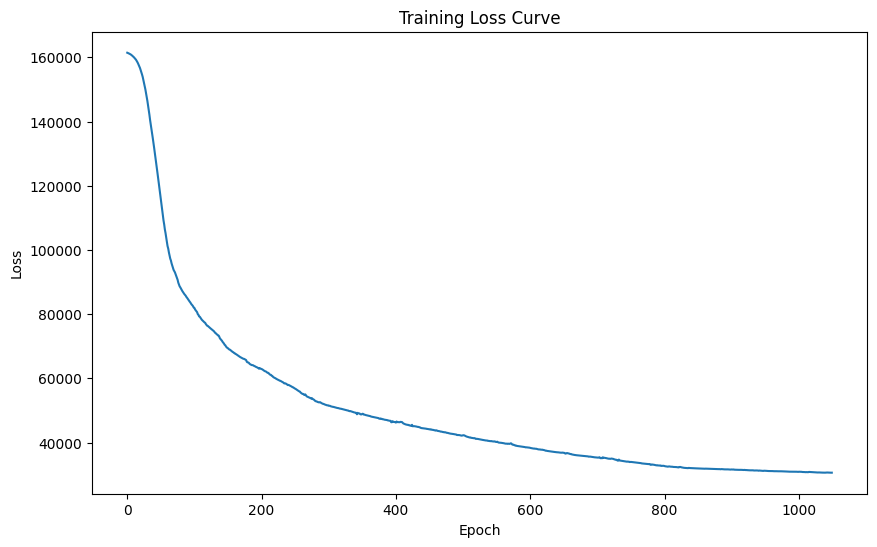

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(mlp.loss_curve_, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')

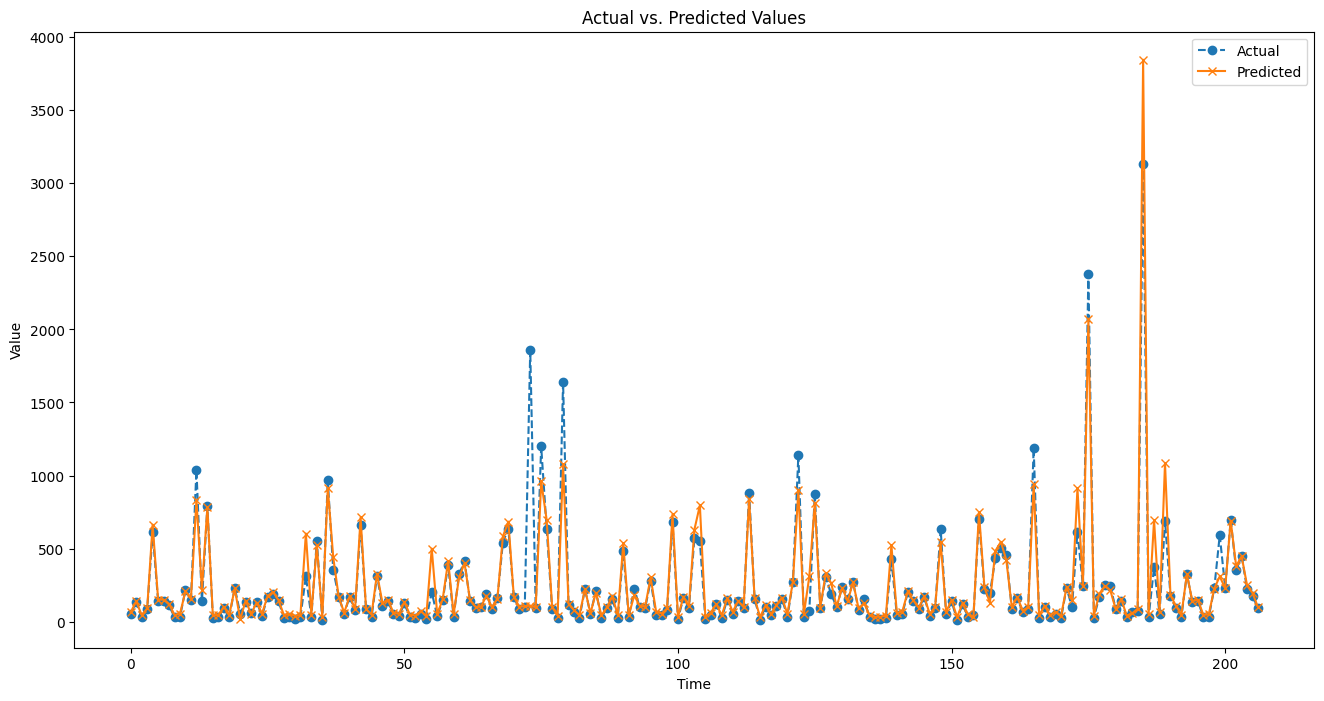

In [27]:
t = range(len(y_test))

plt.figure(figsize=(16,8))
plt.plot(t, y_test, label='Actual', linestyle='--', marker='o')
plt.plot(t, y_test_pred, label='Predicted', linestyle='-', marker='x')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.show()